In [1]:
import pandas as pd
import numpy as np

# Text processing
import re
import string

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

Saving True.csv to True.csv
Saving Fake.csv to Fake.csv


In [3]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

In [4]:
# Add labels
fake["label"] = 0
real["label"] = 1

# Combine
data = pd.concat([fake, real], axis=0)

# Shuffle
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [5]:
# Use title + text as input
data["content"] = data["title"] + " " + data["text"]

# Cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\\W', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

data["content"] = data["content"].apply(clean_text)

In [6]:
X = data["content"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

In [9]:
y_pred = model.predict(X_test_vec)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9354120267260579

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      4710
           1       0.93      0.93      0.93      4270

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980


Confusion Matrix:
 [[4421  289]
 [ 291 3979]]


In [11]:
# Training accuracy
train_pred = model.predict(X_train_vec)
train_acc = accuracy_score(y_train, train_pred)

# Testing accuracy
test_acc = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9454034188986024
Testing Accuracy: 0.9354120267260579


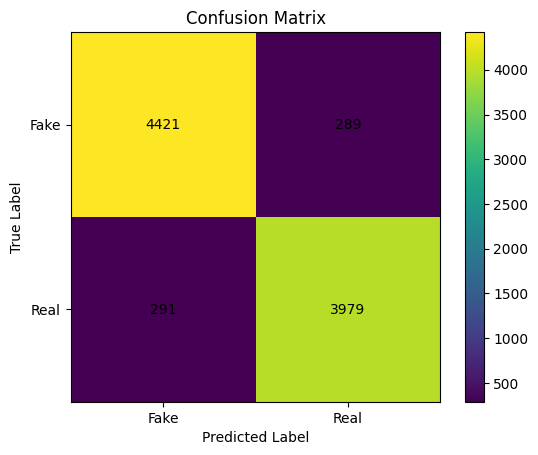

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")

plt.colorbar()

# Axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Tick labels
plt.xticks([0, 1], ["Fake", "Real"])
plt.yticks([0, 1], ["Fake", "Real"])

# Add numbers inside cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

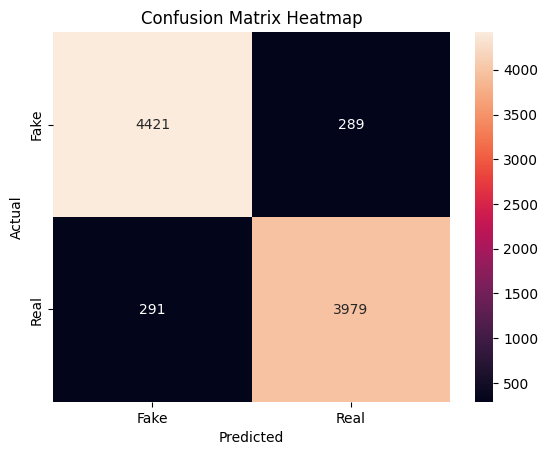

In [13]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()